# Figure 1 Trained Dataset Stats


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import config as c
from violmulti.data.dataset_loader import DatasetLoader
import statsmodels.formula.api as smf
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

%load_ext autoreload
%autoreload 2
sns.set_context("notebook", rc={"font.size": 20, "axes.titlesize": 20, "axes.labelsize": 20, "axes.titleweight": "bold", "xtick.labelsize": 15, "ytick.labelsize": 15})

# Load data
data_loader = DatasetLoader()
data = data_loader.load_new_trained_cleaned()


# Load Data


In [2]:
df = DatasetLoader().load_data()

DataLoader: Loading data type:  new_trained_cleaned  for animal ids:  ['W051', 'W060', 'W065', 'W066', 'W068', 'W072', 'W073', 'W074', 'W075', 'W078', 'W080', 'W081', 'W083', 'W088', 'W089', 'W094']


## Agg


In [23]:
df.delay_time.unique()

array([4., 2., 6., 3., 5., 8., 7.])

In [3]:
# 1. aggregate
perf_agg_df = (
    df
    .groupby(["animal_id","session"])
    .agg(
        hit_rate   = ("hit",       "mean"),
        n_trials   = ("trial",     "max"),
        viol_rate  = ("violation", "mean"),
    )
    .reset_index()
)

In [4]:
len(df)

1866003

In [5]:
perf_agg_df.groupby("animal_id").session.nunique().sum()

5210

# B-E Hit Rate, Trial Rate, and Violation Rate


In [6]:
df.head()

,animal_id,session_date,session_file_counter,rig_id,training_stage,s_a,s_b,hit,violation,trial_not_started,...,r_water_vol,antibias_beta,antibias_right_prob,using_psychometric_pairs,choice,session,session_relative_to_old,n_prev_trial_not_started,trial,animal_id_session
0,W051,2014-07-17,327,19,4,60.0,68.0,NaN,1,False,...,18.000000,3,0.5,NaN,2,326,326.0,0.0,1,W051_s326
1,W051,2014-07-17,327,19,4,60.0,68.0,NaN,1,False,...,18.000001,3,0.5,NaN,2,326,326.0,0.0,2,W051_s326
2,W051,2014-07-17,327,19,4,76.0,68.0,NaN,1,False,...,18.000004,3,0.5,NaN,2,326,326.0,0.0,3,W051_s326
3,W051,2014-07-17,327,19,4,68.0,76.0,1.0,0,False,...,18.000014,3,0.5,NaN,0,326,326.0,0.0,4,W051_s326
4,W051,2014-07-17,327,19,4,84.0,76.0,1.0,0,False,...,18.000033,3,0.5,NaN,1,326,326.0,0.0,5,W051_s326


In [7]:
def plot_histogram(x, color,df=perf_agg_df, **kwargs):
    fig, ax = plt.subplots(figsize=(6,4))
    sns.despine()

    sns.histplot(x=x, data=df, ax=ax, color=color, element="step", alpha = 0.5,**kwargs)

    median_value = df[x].median()
    ax.axvline(median_value, color=color, linestyle="--", label=f"Median: {median_value:.2f}")

    return fig, ax

## Trial


,index,n_trials
0,count,5210.000000
1,mean,358.157965
2,std,140.468588
3,min,50.000000
4,25%,264.000000
5,50%,348.000000
6,75%,432.000000
7,max,1494.000000


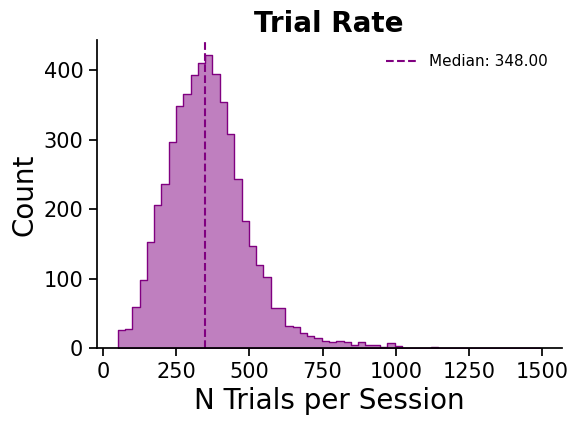

In [8]:
fig, ax = plot_histogram("n_trials", c.N_TRIAL_COLOR, binwidth=25)
ax.set(xlabel="N Trials per Session")
ax.legend(loc="upper right", frameon=False)
ax.set_title("Trial Rate", fontweight="bold")
fig.savefig("figures/fig1_trial_rate.png", dpi=300, bbox_inches="tight")
perf_agg_df.n_trials.describe().reset_index()


## Hit


,index,hit_rate_percentage
0,count,5210.000000
1,mean,81.879281
2,std,6.195436
3,min,27.272727
4,25%,77.702703
5,50%,81.502115
6,75%,86.069093
7,max,97.877358


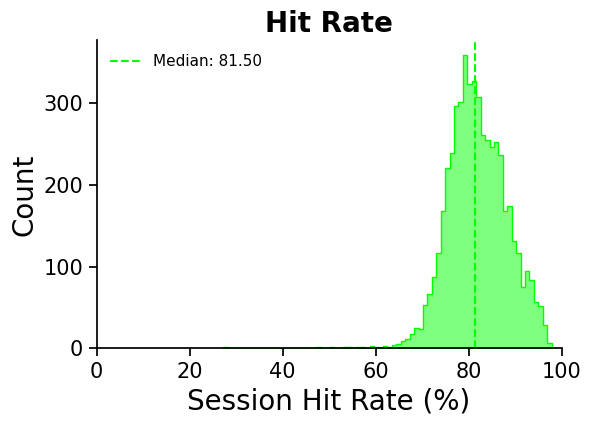

In [9]:

# Multiply hit rate by 100 to convert to percentage
perf_agg_df["hit_rate_percentage"] = perf_agg_df["hit_rate"] * 100

fig, ax = plot_histogram("hit_rate_percentage", c.HIT_COLOR)
ax.set(xlabel="Session Hit Rate (%)", xlim=(0, 100))
ax.legend(loc="upper left", frameon=False)
ax.set_title("Hit Rate", fontweight="bold")
fig.savefig("figures/fig1_hit_rate.png", dpi=300, bbox_inches="tight")
perf_agg_df.hit_rate_percentage.describe().reset_index()

## Violation


,index,viol_rate_percentage
0,count,5210.000000
1,mean,17.421760
2,std,9.166983
3,min,1.345291
4,25%,11.051568
5,50%,15.240999
6,75%,21.401535
7,max,90.350877


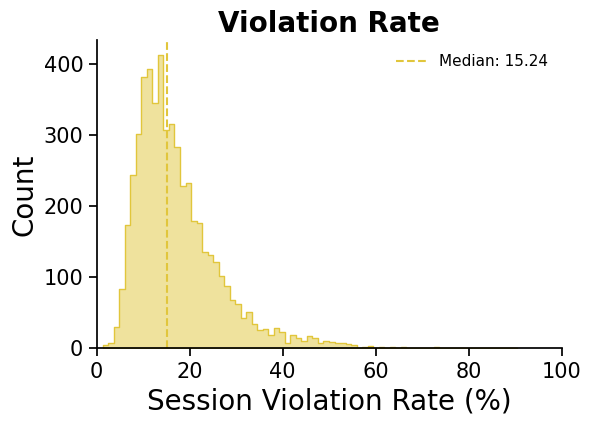

In [10]:
# Multiply violation rate by 100 to convert to percentage
perf_agg_df["viol_rate_percentage"] = perf_agg_df["viol_rate"] * 100

fig, ax = plot_histogram("viol_rate_percentage", c.VIOLATION_COLOR)
ax.set(xlabel="Session Violation Rate (%)", xlim=(0, 100))
ax.legend(loc="upper right", frameon=False)
ax.set_title("Violation Rate", fontweight="bold")
fig.savefig("figures/fig1_violation_rate.png", dpi=300, bbox_inches="tight")
perf_agg_df.viol_rate_percentage.describe().reset_index()

## Choice Distributions


In [11]:
choice_dist_df =df.groupby(["animal_id", "session"]).choice.value_counts(normalize=True).reset_index()
choice_dist_df["Choice"] = choice_dist_df["choice"].map({0: "Left", 1: "Right", 2: "Violation"})
choice_dist_df["percentage"] = choice_dist_df["proportion"] * 100
choice_dist_df["percentage"] = choice_dist_df["percentage"].round(2)

CHOICE_ORDER = ["Left", "Violation", "Right"]
CHOICE_PAL = [c.LEFT_COLOR, c.VIOLATION_COLOR, c.RIGHT_COLOR]

choice_dist_df.to_csv("data/fig1_choice_dist_df.csv", index=False)

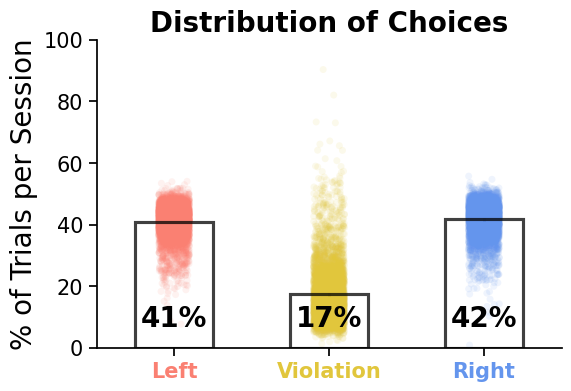

In [12]:

fig, ax = plt.subplots(figsize=(6,4))
sns.despine()

sns.barplot(x="Choice", y="percentage", data=choice_dist_df, ax=ax, width=0.5, fill=False, zorder=10, errorbar="se", color="k", alpha =0.75, order=CHOICE_ORDER, hue_order=CHOICE_ORDER)
sns.stripplot(x="Choice", y="percentage", data=choice_dist_df, ax=ax, alpha=0.10, palette=CHOICE_PAL, hue="Choice", order=CHOICE_ORDER, hue_order=CHOICE_ORDER)
ax.set(xlabel="", ylabel=r"% of Trials per Session", ylim=(0, 100))
ax.set_title("Distribution of Choices", fontweight="bold")

# Add text labels for each Choice group at y=5
for choice in choice_dist_df["Choice"].unique():
    percentage = choice_dist_df[choice_dist_df["Choice"] == choice]["percentage"].mean()
    ax.text(x=choice, y=5, s=f"{percentage:.0f}%", ha='center', va='bottom', fontweight='bold')

# Color the x labels with the corresponding colors from the palette and make them bold
for label in ax.get_xticklabels():
    choice = label.get_text()
    if choice == "Left":
        label.set_color(c.LEFT_COLOR)
    elif choice == "Violation":
        label.set_color(c.VIOLATION_COLOR)
    elif choice == "Right":
        label.set_color(c.RIGHT_COLOR)
    label.set_fontweight('bold')

fig.savefig("figures/fig1_choice_percentages.png", dpi=300, bbox_inches="tight")

# F Trained: Violation Rate by Hit Rate


In [13]:
ylim=(0, 90)
xlim=(50, 100)

In [14]:
plot_df_all = perf_agg_df.copy()
plot_df_all["hit_rate"] *= 100
plot_df_all["viol_rate"] *= 100
plot_df_by_animal = plot_df_all.groupby("animal_id").agg({"hit_rate": "mean", "viol_rate": "mean", "n_trials": "mean"}).reset_index()

plot_df_by_animal.to_csv("data/fig1_animal_agg_perf_df.csv", index=False)

/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_71582/2723801110.py:12: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sns.scatterplot(x="hit_rate", y="viol_rate", data=plot_df_all, ax=ax, hue="animal_id", alpha=0.3, legend=False, palette=palette)
/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_71582/2723801110.py:13: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sns.scatterplot(x="hit_rate", y="viol_rate", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)


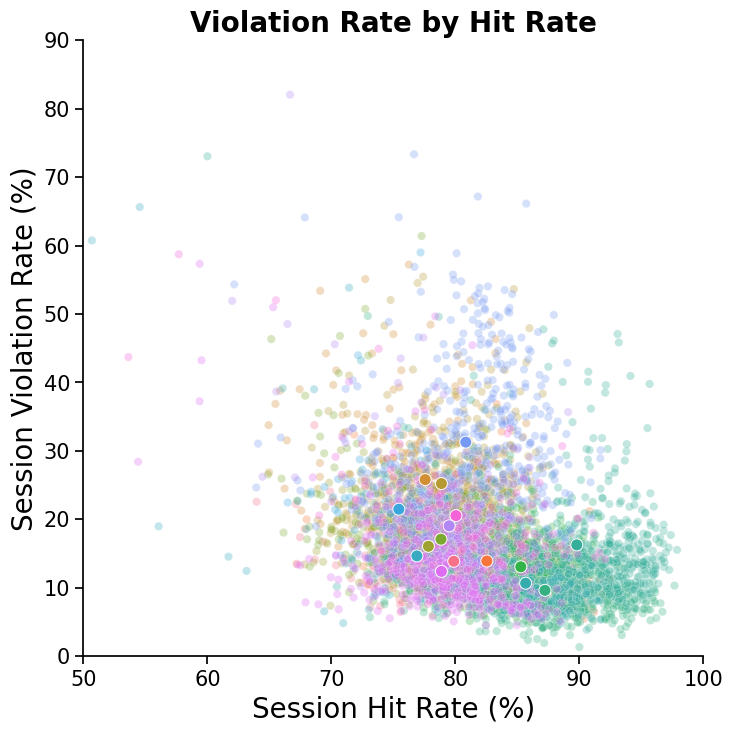

In [15]:
fig, ax = plt.subplots(figsize=(8,8))
sns.despine()
palette = sns.color_palette("husl", 17)

plot_df_all = perf_agg_df.copy()
plot_df_all["hit_rate"] *= 100
plot_df_all["viol_rate"] *= 100
plot_df_by_animal = plot_df_all.groupby("animal_id").agg({"hit_rate": "mean", "viol_rate": "mean", "n_trials": "mean"}).reset_index()



sns.scatterplot(x="hit_rate", y="viol_rate", data=plot_df_all, ax=ax, hue="animal_id", alpha=0.3, legend=False, palette=palette)
sns.scatterplot(x="hit_rate", y="viol_rate", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
ax.set(xlabel="Session Hit Rate (%)", ylabel="Session Violation Rate (%)", xlim=xlim, ylim=ylim)
ax.set_title("Violation Rate by Hit Rate", fontweight="bold")

ax.get_legend().remove()
fig.savefig("figures/fig1_violation_rate_by_hit_rate.png", dpi=300, bbox_inches="tight")

In [16]:
# Define the model with animal_id as a grouping (random intercept)
model = smf.mixedlm("viol_rate ~ hit_rate", data=plot_df_all, groups=plot_df_all["animal_id"])

# Fit the model
result = model.fit()

# Print the model summary
print(result.summary())

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: viol_rate  
No. Observations: 5210    Method:             REML       
No. Groups:       16      Scale:              42.7760    
Min. group size:  114     Log-Likelihood:     -17220.6603
Max. group size:  552     Converged:          Yes        
Mean group size:  325.6                                  
---------------------------------------------------------
              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept     45.222    2.117  21.361 0.000 41.072 49.371
hit_rate      -0.342    0.020 -17.265 0.000 -0.380 -0.303
Group Var     30.495    1.712                            



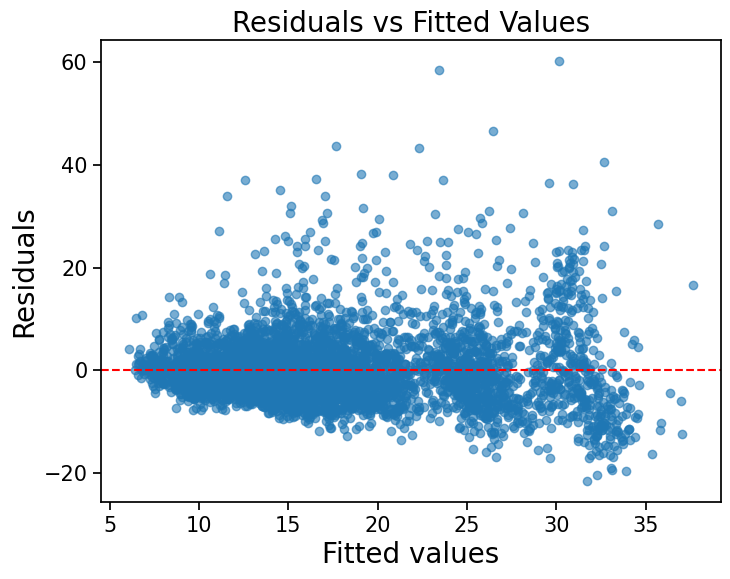

In [17]:
# Extract fitted values and residuals
fitted = result.fittedvalues
residuals = result.resid

plt.figure(figsize=(8, 6))
plt.scatter(fitted, residuals, alpha=0.6)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.axhline(0, color="red", linestyle="--")
plt.show()

In [18]:
# Using the fitted values from the model (includes fixed and random effects)
r2_conditional = r2_score(plot_df_all['viol_rate'], result.fittedvalues)
print("Conditional R-squared:", r2_conditional)

# Extract fixed effect parameters
fixed_intercept = result.fe_params['Intercept']
fixed_slope = result.fe_params['hit_rate']

# Compute predictions using only fixed effects
pred_fixed = fixed_intercept + fixed_slope * plot_df_all['hit_rate']

# Compute marginal R² as the squared correlation between observed values and fixed-effect predictions
r2_marginal = r2_score(plot_df_all['viol_rate'], pred_fixed)
print("Marginal R-squared:", r2_marginal)

Conditional R-squared: 0.4925218266991941
Marginal R-squared: 0.09451056862724316


In [19]:
import statsmodels.api as sm
import pandas as pd

# Add a constant (intercept term) to the model
X = sm.add_constant(plot_df_by_animal[['hit_rate']])
y = plot_df_by_animal['viol_rate']

# Fit the linear regression model
model = sm.OLS(y, X).fit()

# Summary of the model
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              viol_rate   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     3.280
Date:                Tue, 15 Jul 2025   Prob (F-statistic):             0.0916
Time:                        06:44:37   Log-Likelihood:                -49.147
No. Observations:                  16   AIC:                             102.3
Df Residuals:                      14   BIC:                             103.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         69.7131     28.827      2.418      0.0

/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=16
  res = hypotest_fun_out(*samples, **kwds)


In [20]:
# Fit a simple linear regression model
model = LinearRegression()
X = plot_df_by_animal[['hit_rate']]
y = plot_df_by_animal['viol_rate']
model.fit(X, y)

# Generate predictions and compute R-squared
y_pred = model.predict(X)
r2_aggregated = r2_score(y, y_pred)
print("R-squared on aggregated data:", r2_aggregated)
print(f"Slope: {model.coef_[0]}, Intercept: {model.intercept_}")

R-squared on aggregated data: 0.18980415688862085
Slope: -0.6442377553421731, Intercept: 69.7130625690381


/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_71582/2850669578.py:5: UserWarning: The palette list has more values (17) than needed (16), which may not be intended.
  sns.scatterplot(x="hit_rate", y="viol_rate", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


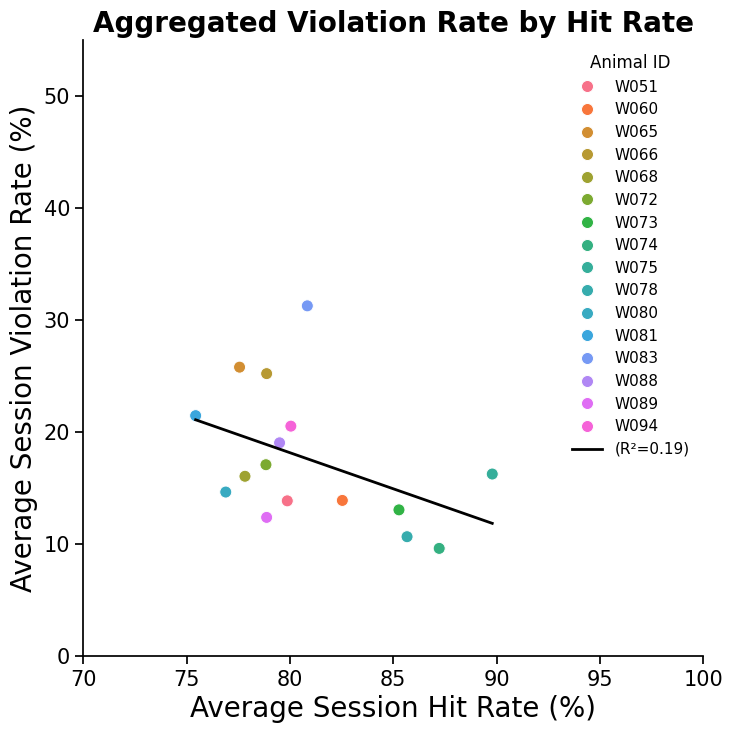

In [21]:
fig, ax = plt.subplots(figsize=(8,8))
sns.despine()
palette = sns.color_palette("husl", 17)

sns.scatterplot(x="hit_rate", y="viol_rate", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
ax.set(xlabel="Average Session Hit Rate (%)", ylabel="Average Session Violation Rate (%)")
ax.set_title("Aggregated Violation Rate by Hit Rate", fontweight="bold")

# Plot the linear regression line in black
# Create x-values spanning the range of hit rates
x_vals = np.linspace(plot_df_by_animal['hit_rate'].min(), plot_df_by_animal['hit_rate'].max(), 100)
# Predict violation rates using the regression model
y_vals = model.predict(x_vals.reshape(-1, 1))
# Plot the regression line
ax.plot(x_vals, y_vals, color='black', linewidth=2, label=f"(R²={r2_aggregated:.2f})")

# Update the legend to include the regression line
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title="Animal ID", frameon=False, loc="upper right")


ax.set(xlim=(70, 100), ylim=(0, 55))
fig.savefig("figures/fig1_violation_rate_by_hit_rate_by_animal.png", dpi=300, bbox_inches="tight")